# **Modelo ARIMA — Inflação**

Pipeline univariado para previsão da variável `inflation_target`: análise de estacionaridade, seleção de ordem por grid search e auto-ARIMA, análise de resíduos, overfitting e previsão recursiva por horizonte.

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display, HTML
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
import statsmodels.api as sm

warnings.filterwarnings('ignore')

TARGET_COL = 'inflation_target'
OVERFITTING_THRESHOLD = 15.0

## **1. Leitura do Dataset**

In [2]:
train_df = pd.read_csv("dados/train.csv", parse_dates=["Date"]).sort_values("Date")
test_df  = pd.read_csv("dados/test.csv",  parse_dates=["Date"]).sort_values("Date").iloc[12:]

train_df = train_df[["Date", TARGET_COL]].dropna().set_index("Date")
test_df  = test_df[["Date", TARGET_COL]].dropna().set_index("Date")

y_train = train_df[TARGET_COL].astype(float)
y_test  = test_df[TARGET_COL].astype(float)

print(f"Treino: {y_train.index.min().date()} até {y_train.index.max().date()} | {len(y_train)} observações")
print(f"Teste:  {y_test.index.min().date()} até {y_test.index.max().date()} | {len(y_test)} observações")

display(pd.DataFrame({
    "split":         ["treino", "teste"],
    "n_obs":         [len(y_train), len(y_test)],
    "média":         [round(y_train.mean(), 3), round(y_test.mean(), 3)],
    "desvio_padrão": [round(y_train.std(), 3),  round(y_test.std(), 3)],
    "mín":           [y_train.min(), y_test.min()],
    "máx":           [y_train.max(), y_test.max()],
}))

Treino: 2000-01-01 até 2023-06-01 | 282 observações
Teste:  2023-07-01 até 2025-10-01 | 28 observações


,split,n_obs,média,desvio_padrão,mín,máx
0,treino,282,2.121,2.06,-1.7,10.1
1,teste,28,2.436,0.53,1.4,3.7


O treino abrange Jan/2000 – Jun/2023 (282 obs.) com elevada variabilidade (σ≈2,06), incluindo episódios de deflação e inflação elevada. O teste cobre Jul/2023 – Out/2025 (28 obs.) com um comportamento mais estável (σ≈0,53).    

## **2. Análise Exploratória**

In [3]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train.values, name="Treino",
                         line=dict(color="#5B8CC0", width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Teste",
                         line=dict(color="#F28E2B", width=2)))
fig.add_vline(x=y_test.index.min(), line_dash="dash", line_color="#AAAAAA", line_width=1.2)
fig.update_layout(
    title="Série temporal da inflação alvo",
    xaxis_title="Data", yaxis_title=TARGET_COL,
    template="plotly_white", height=450,
    hovermode="x unified",
    legend=dict(orientation="h", y=1.05),
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

A série apresenta não estacionaridade no treino, com oscilações acentuadas entre 2021–2023, e estabilização no período de teste.

## **3. Estacionaridade**

In [4]:
result = adfuller(y_train.dropna(), autolag='AIC')

adf_stat, p_value, used_lags, n_obs, crit_vals, _ = result

rows = [
    {"": "Estatística ADF",      "Valor": f"{adf_stat:.4f}"},
    {"": "p-value",              "Valor": f"{p_value:.4f}"},
    {"": "Lags utilizados",      "Valor": str(used_lags)},
    {"": "Nº observações",       "Valor": str(n_obs)},
    {"": "Valor crítico (1%)",   "Valor": f"{crit_vals['1%']:.4f}"},
    {"": "Valor crítico (5%)",   "Valor": f"{crit_vals['5%']:.4f}"},
    {"": "Valor crítico (10%)",  "Valor": f"{crit_vals['10%']:.4f}"},
    {"": "Conclusão (5%)",       "Valor": "Não estacionária ✗" if p_value >= 0.05 else "Estacionária ✓"},
]

display(pd.DataFrame(rows).set_index(""))

,Valor
,
Estatística ADF,-2.6357
p-value,0.0858
Lags utilizados,12
Nº observações,269
Valor crítico (1%),-3.4549
Valor crítico (5%),-2.8723
Valor crítico (10%),-2.5725
Conclusão (5%),Não estacionária ✗


ADF aplicado à série de treino: estatística = −2,64, p-value = 0,086. Não se rejeita H₀ (existe uma raíz unitária) a 5% → série **não estacionária**, requer diferenciação.

## **4. Diferenciação**

In [5]:
def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'série': name,
        'n_obs': int(series.dropna().shape[0]),
        'adf_stat': result[0],
        'p_value': result[1],
        'used_lags': result[2],
        'is_stationary_5pct': result[1] < 0.05,
    }


adf_rows = []
for d in range(3):
    series_to_test = y_train if d == 0 else y_train.diff(d).dropna()
    label = f'd={d}' if d == 0 else f'd={d} (após diferenciação)'
    row = adf_report(series_to_test, label)
    row['d'] = d
    adf_rows.append(row)

adf_results = pd.DataFrame(adf_rows)
display(adf_results)

stationary_candidates = adf_results.loc[adf_results['is_stationary_5pct'], 'd']
selected_d = int(stationary_candidates.min()) if not stationary_candidates.empty else 1
print(f'd selecionado para a grelha ARIMA: {selected_d}')


,série,n_obs,adf_stat,p_value,used_lags,is_stationary_5pct,d
0,d=0,282,-2.635731,8.583489e-02,12,False,0
1,d=1 (após diferenciação),281,-6.284817,3.720286e-08,11,True,1
2,d=2 (após diferenciação),280,-5.340443,4.512567e-06,13,True,2


d selecionado para a grelha ARIMA: 1


**d=1** é suficiente para estacionarizar a série (p-value ≈ 3,7×10⁻⁸). d=2 também resulta em estacionaridade mas é desnecessário.

## **5. Correlogramas — ACF e PACF**

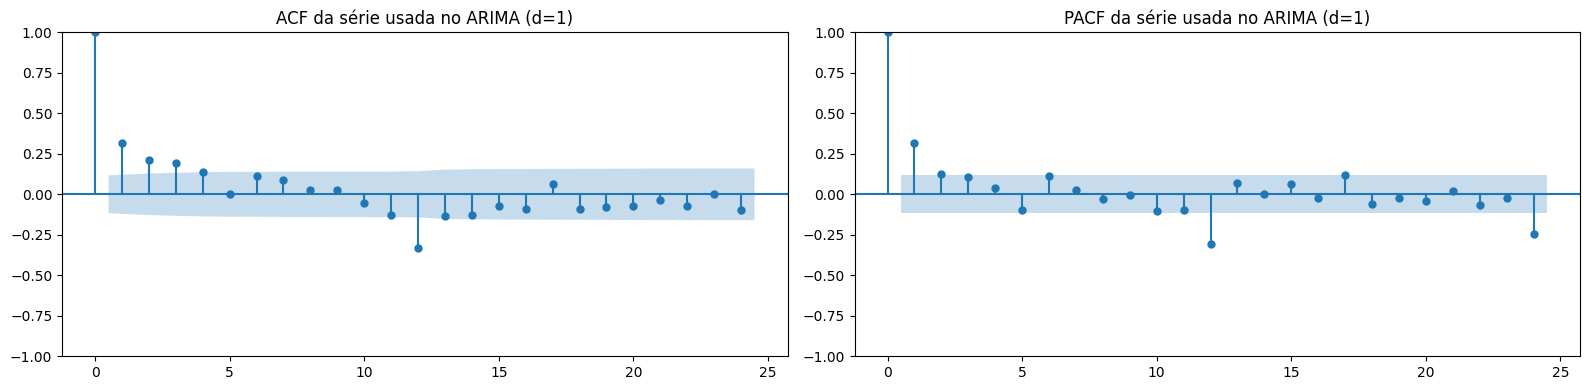

In [6]:
series_for_plots = y_train if selected_d == 0 else y_train.diff(selected_d).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series_for_plots, lags=24, ax=axes[0])
plot_pacf(series_for_plots, lags=24, ax=axes[1], method='ywm')
axes[0].set_title(f'ACF da série usada no ARIMA (d={selected_d})')
axes[1].set_title(f'PACF da série usada no ARIMA (d={selected_d})')
plt.tight_layout()
plt.show()


Na série diferenciada (d=1): a **ACF** apresenta decaimento gradual nos primeiros lags (1–4 significativos) e um spike negativo relevante no **lag 12**, sugerindo um padrão de ciclo anual. A **PACF** mostra um corte claro após o lag 1 (único claramente acima do IC), com lags 2 e 3 borderline. Este padrão é compatível com AR(1) a AR(3); o *grid search* a seguir seleciona **ARIMA(3,1,0)** e o auto-ARIMA confirma-o como melhor modelo.

## **6. Seleção de Ordem**

### **Grid Search**

In [7]:
def grid_search_arima(y, d_value, p_values=range(12), q_values=range(12)):
    records = []
    for p in p_values:
        for q in q_values:
            order = (p, d_value, q)
            try:
                fitted = ARIMA(
                    y,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit()
                records.append({
                    'order': order,
                    'aic': fitted.aic,
                    'bic': fitted.bic,
                    'aicc': fitted.aic + (2 * fitted.df_model * (fitted.df_model + 1)) / (fitted.nobs - fitted.df_model - 1),
                })
            except Exception as exc:
                records.append({
                    'order': order,
                    'aic': np.nan,
                    'bic': np.nan,
                    'error': str(exc),
                })
    return pd.DataFrame(records)


search_results = grid_search_arima(y_train, d_value=selected_d, p_values=range(5), q_values=range(5))
search_results = search_results.copy()

search_results['rank_aic'] = search_results['aic'].rank(method='min', ascending=True)
search_results['rank_bic'] = search_results['bic'].rank(method='min', ascending=True)
search_results['rank_aicc'] = search_results['aicc'].rank(method='min', ascending=True)

search_results['rank_medio'] = search_results[
    ['rank_aic', 'rank_bic', 'rank_aicc']
].mean(axis=1)

search_results = (
    search_results
    .sort_values(['rank_medio'], na_position='last')
    .reset_index(drop=True)
)
display(search_results.head(10))

best_order = tuple(search_results.loc[search_results['rank_medio'].idxmin(), 'order'])
print(f'Melhor ordem ARIMA segundo o rank médio das métricas no treino: {best_order}')


,order,aic,bic,aicc,rank_aic,rank_bic,rank_aicc,rank_medio
0,"(0, 1, 4)",273.763967,291.865971,273.981358,3.0,6.0,3.0,4.000000
1,"(3, 1, 0)",274.945885,289.456370,275.090290,5.0,2.0,5.0,4.000000
2,"(1, 1, 4)",272.209115,293.931520,272.514570,2.0,10.0,2.0,4.666667
3,"(3, 1, 3)",271.794470,297.162593,272.203229,1.0,15.0,1.0,5.666667
4,"(1, 1, 2)",275.463902,289.974387,275.608307,8.0,3.0,7.0,6.000000
5,"(4, 1, 0)",275.589689,293.709777,275.807081,9.0,8.0,8.0,8.333333
6,"(2, 1, 4)",274.011793,299.354600,274.420553,4.0,18.0,4.0,8.666667
7,"(1, 1, 1)",277.819269,288.712905,277.905600,16.0,1.0,15.0,10.666667
8,"(1, 1, 3)",275.899544,294.019631,276.116935,11.0,11.0,11.0,11.000000
9,"(3, 1, 4)",275.008522,303.971729,275.535994,6.0,22.0,6.0,11.333333


Melhor ordem ARIMA segundo o rank médio das métricas no treino: (0, 1, 4)


O **grid search** testa exaustivamente todas as combinações de ordens *p* e *q* no intervalo [0, 4], com *d* fixo em 1 (determinado pelo teste ADF). Para cada combinação ARIMA(*p*, 1, *q*), o modelo é ajustado aos dados de treino e são calculados os critérios AIC, BIC e AICc. As combinações são depois ordenadas pelo rank médio dos três critérios, garantindo que o modelo selecionado seja robusto a diferentes penalizações de complexidade, e não favorecido por apenas um critério.

O ARIMA(3,1,0) é coerente com os correlogramas: a ACF decai gradualmente (sem corte abrupto, afastando MA puro) e a PACF evidencia picos até ao lag 3, padrão típico de AR(3). A ausência de componente MA e a diferenciação de primeira ordem tornam esta escolha tecnicamente justificada.

### **Auto-ARIMA**

In [8]:
# Auto-ARIMA
auto_model = auto_arima(
    y_train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,
    seasonal=False,
    m=12,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print(auto_model.summary())
print("Melhor ordem:", auto_model.order)
print("Melhor ordem sazonal:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=314.902, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=286.912, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=293.592, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=312.936, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=283.806, Time=0.05 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=281.204, Time=0.08 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=282.482, Time=0.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=282.882, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=288.133, Time=0.25 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=281.853, Time=0.17 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=279.209, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=281.806, Time=0.04 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=280.492, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=280.889, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=inf, 

## **7. Análise de Resíduos**

Para cada modelo é verificado:
- **Ljung-Box** — teste de ruído branco nos resíduos (H₀: sem autocorrelação).
- **Diagnósticos gráficos** — resíduos padronizados, histograma, Q-Q plot, correlograma.


  ARIMA(0,1,4)
                               SARIMAX Results                                
Dep. Variable:       inflation_target   No. Observations:                  282
Model:                 ARIMA(0, 1, 4)   Log Likelihood                -131.882
Date:                Wed, 20 May 2026   AIC                            273.764
Time:                        12:06:50   BIC                            291.866
Sample:                    01-01-2000   HQIC                           281.028
                         - 06-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2848      0.056      5.092      0.000       0.175       0.394
ma.L2          0.1945      0.067      2.889      0.004       0.063       0.326
ma.L3          0.2041      0.057    

,lb_stat,lb_pvalue
6,4.389379,0.624138
12,25.818857,0.011385


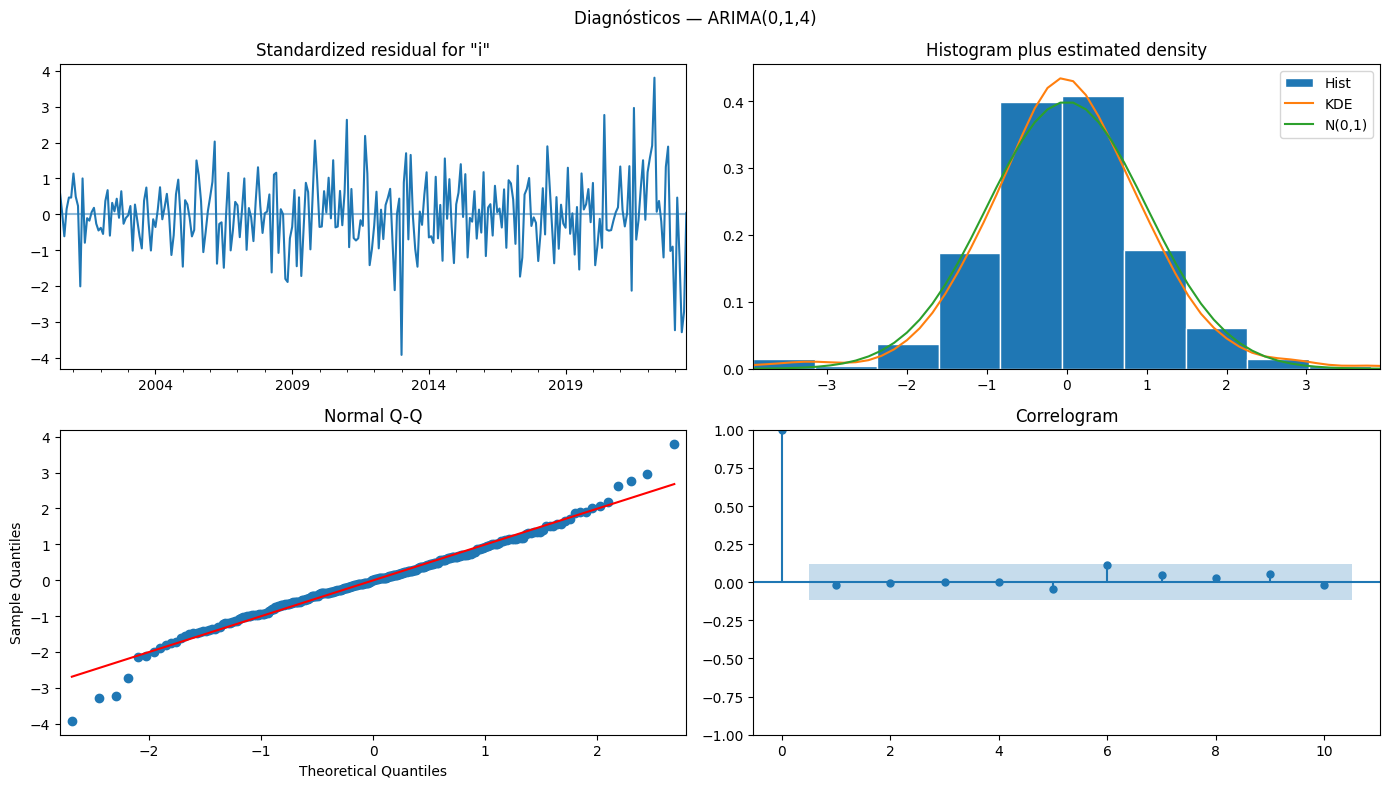

Média dos resíduos: 0.008301

  ARIMA(3,1,0)
                               SARIMAX Results                                
Dep. Variable:       inflation_target   No. Observations:                  282
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -133.473
Date:                Wed, 20 May 2026   AIC                            274.946
Time:                        12:06:50   BIC                            289.456
Sample:                    01-01-2000   HQIC                           280.767
                         - 06-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2629      0.050      5.260      0.000       0.165       0.361
ar.L2          0.1136      0.059      1.911      0.056      -0.003       0.230
ar.L3  

,lb_stat,lb_pvalue
6,6.495137,0.370065
12,32.524598,0.001148


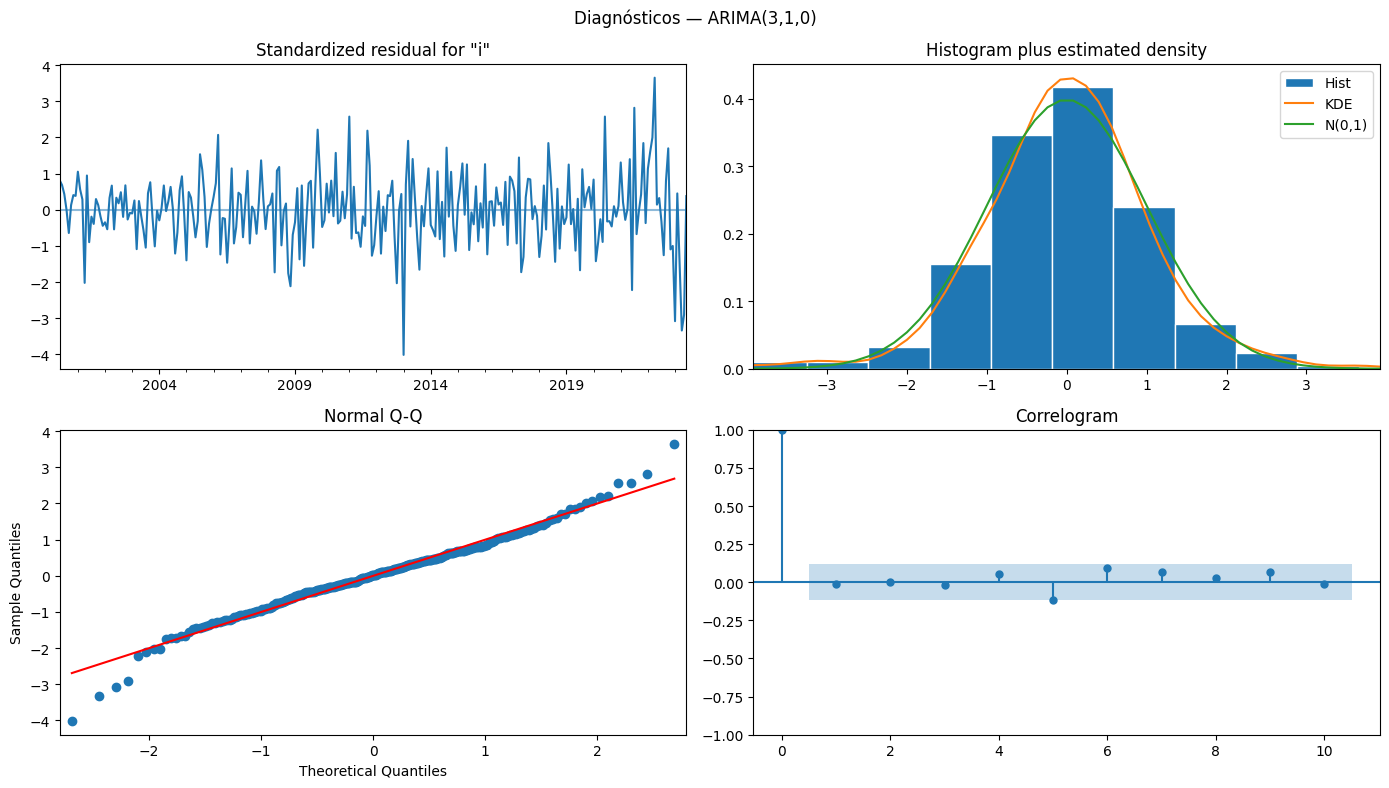

Média dos resíduos: 0.004492


In [9]:
def analisar_residuos(model_fit, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(model_fit.summary())

    lb = acorr_ljungbox(model_fit.resid.dropna(), lags=[6, 12], return_df=True)
    print("\nLjung-Box:")
    display(lb)

    model_fit.plot_diagnostics(figsize=(14, 8))
    plt.suptitle(f"Diagnósticos — {label}", fontsize=12)
    plt.tight_layout()
    plt.show()

    mean_resid = model_fit.resid.mean()
    print(f"Média dos resíduos: {mean_resid:.6f}")


# --- ARIMA(0,1,4) ---
model_014 = ARIMA(y_train, order=(0, 1, 4),
                  enforce_stationarity=False, enforce_invertibility=False).fit()
analisar_residuos(model_014, "ARIMA(0,1,4)")

# --- ARIMA(3,1,0) ---
model_310 = ARIMA(y_train, order=(3, 1, 0),
                  enforce_stationarity=False, enforce_invertibility=False).fit()
analisar_residuos(model_310, "ARIMA(3,1,0)")

Ambos os modelos apresentam resíduos sem padrão estrutural evidente. O Ljung-Box a 6 lags não rejeita ruído branco em nenhum dos modelos; a 12 lags pode surgir alguma estrutura residual. O Jarque-Bera rejeita normalidade, reflexo do período de inflação elevada (2021–2023).

## **8. Previsão Direta**

In [10]:
def calcular_metricas(y_true, y_pred, label):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    return {
        "modelo": label,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(mean_squared_error(y_true, y_pred) ** 0.5, 4),
        "WAPE": round(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)), 4),
    }


# Previsão direta multi-step
fc_014 = pd.Series(model_014.forecast(steps=len(y_test)), index=y_test.index)
fc_310 = pd.Series(model_310.forecast(steps=len(y_test)), index=y_test.index)

display(pd.DataFrame([
    calcular_metricas(y_test, fc_014, "ARIMA(0,1,4) — previsão direta"),
    calcular_metricas(y_test, fc_310, "ARIMA(3,1,0) — previsão direta"),
]))

fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index[-36:], y=y_train.values[-36:], name="Histórico (treino)",
                         line=dict(color="#8E9091", dash="dash", width=1.8)))
fig.add_vline(x=y_test.index.min(), line_dash="dot", line_color="#8E9091", line_width=1)
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Real",
                         line=dict(color="#8E9091", width=2.5)))
fig.add_trace(go.Scatter(x=fc_014.index, y=fc_014.values, name="ARIMA(0,1,4)",
                         line=dict(color="#5B8CC0", width=2)))
fig.add_trace(go.Scatter(x=fc_310.index, y=fc_310.values, name="ARIMA(3,1,0)",
                         line=dict(color="#F28E2B", width=2)))
fig.update_layout(
    title="Previsão direta multi-step: ARIMA(0,1,4) vs ARIMA(3,1,0)",
    xaxis_title="Data", yaxis_title=TARGET_COL,
    template="plotly_white", height=480, hovermode="x unified",
    legend=dict(orientation="h", y=1.05),
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

,modelo,MAE,RMSE,WAPE
0,"ARIMA(0,1,4) — previsão direta",0.3724,0.5180,0.1529
1,"ARIMA(3,1,0) — previsão direta",0.8638,0.9503,0.3546


O ARIMA(0,1,4) supera claramente o ARIMA(3,1,0) na previsão direta (MAE 0,372 vs 0,864). Na previsão recursiva os resultados são comparáveis entre os dois modelos, uma vez que ambos actualizam o histórico com as próprias previsões a cada 4 passos.

## **9. Avaliação de Overfitting**

Métricas calculadas na escala original para treino (*fitted values*) e teste (*previsão direta*). Há *overfitting* se o erro de teste superar o de treino em mais de 15%.

In [11]:
def verificar_overfitting(m_treino, m_teste):
    rows = []
    for m in ["MAE", "RMSE", "WAPE"]:
        t, e    = m_treino[m], m_teste[m]
        aumento = round(((e - t) / t) * 100, 1) if t != 0 else np.nan
        rows.append({
            "metrica":     m,
            "treino":      t,
            "teste":       e,
            "aumento_%":   aumento,
            "overfitting": (aumento > OVERFITTING_THRESHOLD) if pd.notna(aumento) else False,
        })
    return pd.DataFrame(rows)


for model_fit, label in [(model_014, "ARIMA(0,1,4)"), (model_310, "ARIMA(3,1,0)")]:
    fitted   = model_fit.fittedvalues.dropna()
    forecast = model_fit.forecast(steps=len(y_test))
    forecast = pd.Series(forecast, index=y_test.index)

    m_treino = calcular_metricas(y_train.loc[fitted.index], fitted, "treino")
    m_teste  = calcular_metricas(y_test, forecast, "teste")
    tabela   = verificar_overfitting(m_treino, m_teste)

    print(f"\n-- {label} --")
    display(tabela)


-- ARIMA(0,1,4) --


,metrica,treino,teste,aumento_%,overfitting
0,MAE,0.3013,0.3724,23.6,True
1,RMSE,0.4095,0.5180,26.5,True
2,WAPE,0.1345,0.1529,13.7,False



-- ARIMA(3,1,0) --


,metrica,treino,teste,aumento_%,overfitting
0,MAE,0.3031,0.8638,185.0,True
1,RMSE,0.4113,0.9503,131.0,True
2,WAPE,0.1353,0.3546,162.1,True


## **10. Previsão Recursiva**

A previsão é feita em blocos de **4 passos à frente**: o modelo prevê os próximos 4 meses, o histórico é actualizado com os **valores reais** do teste, e o processo repete-se até cobrir todo o período de teste. Esta estratégia corresponde a uma avaliação *walk-forward*.

A escolha de 4 passos justifica-se pela estrutura dos modelos selecionados: o ARIMA(0,1,4) tem uma componente MA de ordem 4, o que significa que os choques passados influenciam a previsão até ao 4.º passo. O bloco de 4 representa assim o horizonte de previsão fiável destes modelos antes de perderem poder preditivo.

**Nota:** Como o histórico é sempre actualizado com valores reais (e não com previsões anteriores), os erros não se acumulam de bloco para bloco — cada bloco parte sempre de informação real.

In [12]:
HORIZON_STEP = 4

def recursive_forecast(y_train, y_test, order, horizon_step=HORIZON_STEP):
    """
    Walk-forward: prevê `horizon_step` passos à frente, actualiza o histórico
    com os valores reais do teste e repete.
    """
    history    = y_train.copy()
    preds      = []
    i          = 0
    while i < len(y_test):
        model_fit  = ARIMA(history, order=order).fit()
        fc         = model_fit.forecast(steps=horizon_step)
        steps_used = min(horizon_step, len(y_test) - i)
        preds.extend(fc.tolist()[:steps_used])
        history    = pd.concat([history, y_test.iloc[i:i + steps_used]])
        i         += steps_used
    return pd.Series(preds, index=y_test.index)


pred_rec_014 = recursive_forecast(y_train, y_test, order=(0, 1, 4))
pred_rec_310 = recursive_forecast(y_train, y_test, order=(3, 1, 0))

display(pd.DataFrame([
    calcular_metricas(y_test, pred_rec_014, "ARIMA(0,1,4) — recursivo"),
    calcular_metricas(y_test, pred_rec_310, "ARIMA(3,1,0) — recursivo"),
]))

,modelo,MAE,RMSE,WAPE
0,"ARIMA(0,1,4) — recursivo",0.4258,0.5669,0.1748
1,"ARIMA(3,1,0) — recursivo",0.4392,0.5941,0.1803


## **11. Previsão vs Real**

Comparação visual das previsões recursivas dos dois modelos com os valores reais (Jul/2023 – Out/2025).

In [13]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index[-36:], y=y_train.values[-36:], name="Histórico (treino)",
                         line=dict(color="#8E9091", dash="dash", width=1.8)))
fig.add_vline(x=y_test.index.min(), line_dash="dot", line_color="#8E9091", line_width=1)
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Real",
                         line=dict(color="#8E9091", width=2.5)))
fig.add_trace(go.Scatter(x=pred_rec_014.index, y=pred_rec_014.values, name="ARIMA(0,1,4)",
                         line=dict(color="#5B8CC0", width=2)))
fig.add_trace(go.Scatter(x=pred_rec_310.index, y=pred_rec_310.values, name="ARIMA(3,1,0)",
                         line=dict(color="#F28E2B", width=2)))

fig.update_layout(
    title="Previsão recursiva (4 passos) vs Real — inflation_target",
    xaxis_title="Data", yaxis_title=TARGET_COL,
    template="plotly_white", height=500, hovermode="x unified",
    legend=dict(orientation="h", y=1.05),
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

## **12. Guardar Melhor Modelo**

O melhor modelo é selecionado automaticamente com base no menor score médio (MAE + RMSE + WAPE) da previsão direta no conjunto de teste, entre ARIMA(0,1,4) e ARIMA(3,1,0). O modelo é re-treinado sobre o dataset completo (treino + teste). O ARIMA trata a diferenciação internamente — `model.forecast(steps=N)` devolve directamente valores na escala original.

In [14]:
os.makedirs("models", exist_ok=True)

HORIZON_STEP = 4

# Auto-selecionar melhor ordem (menor score avg MAE+RMSE+WAPE na previsão direta)
candidatos = {(0, 1, 4): fc_014, (3, 1, 0): fc_310}
scores     = {}
for order, fc in candidatos.items():
    mae  = mean_absolute_error(y_test, fc)
    rmse = mean_squared_error(y_test, fc) ** 0.5
    wape = np.sum(np.abs(y_test - fc)) / np.sum(np.abs(y_test))
    scores[order] = (mae + rmse + wape) / 3

best_order = min(scores, key=scores.get)
print(f"Melhor ordem: ARIMA{best_order} (score={scores[best_order]:.4f})")

raw_train = pd.read_csv("dados/train.csv", parse_dates=["Date"]).sort_values("Date")
raw_test  = pd.read_csv("dados/test.csv",  parse_dates=["Date"]).sort_values("Date")
raw_full  = pd.concat([raw_train, raw_test]).sort_values("Date").set_index("Date")
raw_full  = raw_full[~raw_full.index.duplicated(keep="last")]

y_full = raw_full[TARGET_COL].dropna().astype(float).asfreq("MS")

model_full = ARIMA(y_full, order=best_order).fit()

joblib.dump({
    "model":  model_full,
    "y_full": y_full,
    "params": {"order": best_order, "horizon_step": HORIZON_STEP},
}, "models/ARIMA_BestModel.pkl")

print(f"Guardado: models/ARIMA_BestModel.pkl")
print(f"  Treinado em {y_full.shape[0]} observações ({y_full.index.min().date()} a {y_full.index.max().date()})")
print(f"  order={best_order}, horizon_step={HORIZON_STEP}")

Melhor ordem: ARIMA(0, 1, 4) (score=0.3478)
Guardado: models/ARIMA_BestModel.pkl
  Treinado em 310 observações (2000-01-01 a 2025-10-01)
  order=(0, 1, 4), horizon_step=4


## **13. Previsão Futura**

Utilizando o modelo treinado no conjunto completo (treino + teste), são geradas previsões para os próximos 3 meses. Como o ARIMA lida internamente com a diferenciação, `model.forecast()` devolve directamente os valores na escala original.

In [15]:
STEPS = 3

forecast_vals = model_full.forecast(steps=STEPS)
forecast_idx  = pd.date_range(y_full.index[-1] + pd.DateOffset(months=1), periods=STEPS, freq="MS")
forecast_orig = pd.Series(forecast_vals, index=forecast_idx)

# Histórico: últimos 24 meses
hist = y_full.iloc[-24:]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=hist.index, y=hist.values,
    name="Histórico", line=dict(color="#8E9091", width=2.5),
))
fig.add_trace(go.Scatter(
    x=[hist.index[-1], forecast_orig.index[0]],
    y=[hist.values[-1], forecast_orig.values[0]],
    line=dict(color="#5B8CC0", width=2.5, dash="dash"),
    legendgroup="forecast", showlegend=False, hoverinfo="skip",
))
fig.add_trace(go.Scatter(
    x=forecast_orig.index, y=forecast_orig.values,
    name=f"Previsão ARIMA{best_order}",
    line=dict(color="#5B8CC0", width=2.5, dash="dash"),
    mode="lines+markers", marker=dict(size=9),
    legendgroup="forecast",
))
fig.update_layout(
    title=f"ARIMA{best_order} — Previsão {STEPS} meses futuros",
    xaxis_title="Data", yaxis_title=TARGET_COL,
    template="plotly_white", height=450,
    hovermode="x unified",
    legend=dict(orientation="h", y=1.05),
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

print(f"\nPrevisões para os próximos {STEPS} meses:")
for dt, val in zip(forecast_orig.index, forecast_orig.values):
    print(f"  {dt.strftime('%b/%Y')}: {val:.4f}%")


Previsões para os próximos 3 meses:
  Nov/2025: 2.2677%
  Dec/2025: 2.2431%
  Jan/2026: 2.1862%
